## Importing the libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import optuna
from sklearn. metrics import classification_report
import joblib

c:\Users\HP\Documents\Data\Titanic_Survival_Prediction\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the dataset

In [4]:
titanic_df = pd.read_csv(r"C:\Users\HP\Documents\Data\Titanic_Survival_Prediction\Data\titanic.csv")

In [5]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Basic checks

In [6]:
def basic_checks(df):
    print("-"*40, "Shape", "-"*40)
    print(df.shape)
    print("-"*40, "Columns", "-"*40)
    print(df.columns)
    print("-"*40, "Duplicates", "-"*40)
    print(df.duplicated().sum())
    print("-"*40, "Missing Values", "-"*40)
    print(df.isnull().sum())
    print("-"*40, "Data Types", "-"*40)
    print(df.dtypes)

In [7]:
basic_checks(titanic_df)

---------------------------------------- Shape ----------------------------------------
(891, 12)
---------------------------------------- Columns ----------------------------------------
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
---------------------------------------- Duplicates ----------------------------------------
0
---------------------------------------- Missing Values ----------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
---------------------------------------- Data Types ----------------------------------------
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float6

#### Categorical Columns

In [8]:
categorical_columns = ['Pclass', 'Sex', 'Embarked']

for col in categorical_columns:
    print('-'*40, col, '-'*40)
    print(titanic_df[col].unique())

---------------------------------------- Pclass ----------------------------------------
[3 1 2]
---------------------------------------- Sex ----------------------------------------
<StringArray>
['male', 'female']
Length: 2, dtype: str
---------------------------------------- Embarked ----------------------------------------
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [9]:
(titanic_df.isnull().sum() / len(titanic_df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

__Dropping the Cabin column__

In [10]:
titanic_df = titanic_df.drop(columns=['Cabin'])

In [11]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

#### Distribution of the target class

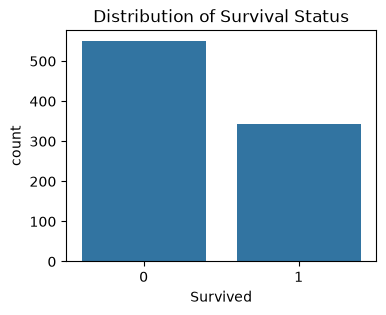

In [12]:
plt.figure(figsize=(4,3))
sns.countplot(titanic_df, x='Survived')
plt.title('Distribution of Survival Status')
plt.xlabel('Survived')
plt.show()

#### Splitting the target and the features

In [13]:
X = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived'])
y = titanic_df['Survived']

#### Separating Numerical and Categorical columns

In [14]:
numerical_columns = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_columns = ['Pclass', 'Sex', 'Embarked']

#### Splitting into training and test datasets

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

#### Creating Numerical Pipelines

In [16]:
numerical_pipeline = Pipeline(steps=[
                                    ('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())
                                    ])

categorical_pipeline = Pipeline(steps=[
                                      ('imputer', SimpleImputer(strategy='most_frequent')),
                                      ('encoder', OneHotEncoder(handle_unknown='ignore'))
                                      ])

#### Combining both preprocessing pipelines

In [17]:
preprocessor = ColumnTransformer(transformers=[
                                              ('num', numerical_pipeline, numerical_columns),
                                              ('cat', categorical_pipeline, categorical_columns)
])

#### Defining the machine learning models we'll use

In [18]:
models = {
          'logistic_regression' : LogisticRegression(max_iter=1000),
          'kneighbours' : KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
          'random_forest' : RandomForestClassifier(n_estimators=300, max_depth=15),
          'svm' : SVC(kernel='rbf', random_state=42, probability=True),
          'gradient_boosting' : GradientBoostingClassifier(n_estimators=300, max_depth=15)
}

#### Cross validation
![Cross validation](https://miro.medium.com/v2/resize:fit:720/format:webp/1*GhKMAUmi4bfFiEwZCPlDsA.png)

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ('preprocessor', preprocessor),
                                ('model', model)
    ])

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring='f1', n_jobs=-1)

    results[model_name] = {'mean_cv_f1' : cv_scores.mean(),
                           'std_cv_f1' : cv_scores.std()
                           }

    print(f'{model_name}')
    print(f'f1_scores {cv_scores}')

logistic_regression
f1_scores [0.73394495 0.70707071 0.74285714 0.7047619  0.76190476]
kneighbours
f1_scores [0.73584906 0.70588235 0.75510204 0.69158879 0.70833333]
random_forest
f1_scores [0.75229358 0.71028037 0.75       0.70175439 0.76470588]
svm
f1_scores [0.78504673 0.7254902  0.78       0.71698113 0.71578947]
gradient_boosting
f1_scores [0.7047619  0.66666667 0.69811321 0.74576271 0.71428571]


In [20]:
results_df = pd.DataFrame(results).T
results_df.head()

,mean_cv_f1,std_cv_f1
logistic_regression,0.730108,0.021732
kneighbours,0.719351,0.022908
random_forest,0.735807,0.024978
svm,0.744662,0.031136
gradient_boosting,0.705918,0.025536


logistic_regression
roc_auc_scores [0.85630165 0.82345041 0.87722048 0.83322811 0.87584175]
kneighbours
roc_auc_scores [0.82272727 0.8464876  0.9031348  0.82817761 0.84090909]
random_forest
roc_auc_scores [0.84338843 0.85320248 0.87763845 0.86837121 0.86132155]
svm
roc_auc_scores [0.85630165 0.81105372 0.90125392 0.84774832 0.83922559]


c:\Users\HP\Documents\Data\Titanic_Survival_Prediction\env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


gradient_boosting
roc_auc_scores [0.84597107 0.82159091 0.83605016 0.86921296 0.86742424]


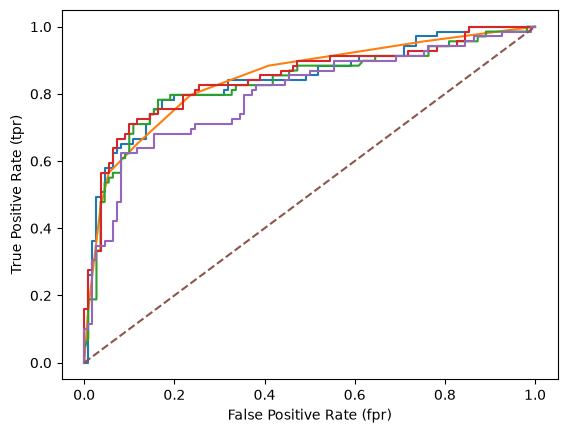

In [21]:
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
                                ('preprocessor', preprocessor),
                                ('model', model)
    ])

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring='roc_auc', n_jobs=-1)

    results[model_name] = {'mean_cv_roc_auc' : cv_scores.mean(),
                           'std_cv_roc_auc' : cv_scores.std()
                           }

    print(f'{model_name}')
    print(f'roc_auc_scores {cv_scores}')

    pipeline.fit(X_train, y_train)
    # Get the probability of the positive class(Survived = 1)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Calculate the roc_auc score (auc -> Area Under Curve)
    auc_score = roc_auc_score(y_test, y_prob)

    # Calculate the points for roc curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Plotting the models roc_curve
    plt.plot(fpr, tpr, label=f"{model_name} (auc = {auc_score})")

plt.plot([0, 1], ls='--', label='RandomForestClassifier auc=0.50')
plt.xlabel('False Positive Rate (fpr)')
plt.ylabel('True Positive Rate (tpr)')
plt.show()

![](https://blog.alliedoffsets.com/hs-fs/hubfs/0_VmdsukltMmSfn1iK.webp?width=1280&height=960&name=0_VmdsukltMmSfn1iK.webp)

## 26th August 2026

### Hyperparameter Tuning
It is the process of choosing the best configuration settings e.g max_steps, n_estimators, entropy, etc to get the best results.

__Types of hyperparameter tuning__
1. Grid search cv(cross validation)
2. Randomized search cv(cross validation)
3. Optuna - uses Bayes theory, also known as Bayesian optimization

__Hyperparameters used in RandomForest:__
n_estimators
max_step
minimum_samples_split
minumum_samples_leaf

#### Grid search cv
Evaluates every hyperprameter combination that you'll give it.
```python
grid_params = {
                'model_n_estimators' : [100, 200, 300],
                'model_max_depth' : [None, 5, 10],
                'model_min_samples_split' : [2, 5],
                'model_min_samples_leaf' : [1, 2]
}
```
_Example_
```python
RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1) # 1st run
RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2) # 2nd run
RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=5, min_samples_leaf=1) # 3rd run
RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=5, min_samples_leaf=2) # 4th run
RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1) # 5th run etc.
# Will continue until it has run all possible combinations(36 in this case)
```

__Disadvantages__
- Curse of dimensionality - as you add more hyperparameters, the number of combinations increases exponentially making the search very slow and expensive.
- It is blind and inefficient - it tests every single combination regardless of whether it works well, wasting time on poor or redundant configurations.
- Discrete limitations - it only checks specific pre-defined values, meaning it can easily miss the optimal value value if it falls between 2 grid points.

In [22]:
3 * 3 * 2 * 2

36

In [23]:
RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
grid_params = {
                'model__n_estimators' : [100, 200, 300],
                'model__max_depth' : [None, 5, 10],
                'model__min_samples_split' : [2, 5],
                'model__min_samples_leaf' : [1, 2]
}

total_grid_combinations = np.prod([len(values) for values in grid_params.values()])
print('Parameter combinations:', total_grid_combinations)

Parameter combinations: 36


In [25]:
rf_pipeline = Pipeline(steps=[
                             ('preprocessor', preprocessor),
                             ('model', RandomForestClassifier())
])

grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=grid_params, scoring='f1', cv=cv)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionch

In [26]:
print('Best grid search f1 score: ', grid_search.best_score_)
print('Best parameters: ', grid_search.best_params_)

Best grid search f1 score:  0.7547156171337036
Best parameters:  {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}


#### Randomized search cv
- Randomized search cv is a tool that optimizes machine learning model hyperparameters by randomly sampling a fixed number of parameter combinations from specified distribution.
- Instead of testing every single combination like grid search cv, it evaluates a random subset determined by the n_iter parameter.

__Advantages__
- More efficient and much faster than grid search cv when dealing with large such spaces or many hyperparameters

__Limitations__
- No optimal guarantee - it may completely miss the best hyperparameter optimization because it samples them randomly.
- Redundant sampling where random selection can repeatedly sample highly similar or identical parameter clusters.

In [27]:
random_params = {
                'model__n_estimators' : [100, 200, 300, 400, 500, 600],
                'model__max_depth' : [None, 4, 5, 6, 7, 10],
                'model__min_samples_split' : [2, 3, 4, 5],
                'model__min_samples_leaf' : [1, 2, 3, 4]                
}

random_search = RandomizedSearchCV(estimator=rf_pipeline, param_distributions=random_params, n_iter=30, scoring='f1', cv=cv, random_state=42)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 4, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dir

In [28]:
print('Best randomized search cv f1 score: ', random_search.best_score_)
print('Best parameters:')
print(random_search.best_params_)

Best randomized search cv f1 score:  0.7554367325795897
Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}


## 27th August 2026

### Bayesian Optimization/Optuna

In [29]:
def objective(trial):
    params = {
              'n_estimators' : trial.suggest_int('n_estimators', 100, 1000),
              'max_depth' : trial.suggest_int('max_depth', 3, 30),
              'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
              'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 20)
    }

    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

    pipeline = Pipeline(steps=[
                              ('preprocessor', preprocessor),
                              ('model', rf)
    ])

    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    return score.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-08-31 08:15:16,660] A new study created in memory with name: no-name-5e8b39f2-bc78-4e51-b47c-6556883f5837


[I 2026-08-31 08:15:44,922] Trial 0 finished with value: 0.7095842369434393 and parameters: {'n_estimators': 615, 'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.7095842369434393.
[I 2026-08-31 08:16:05,024] Trial 1 finished with value: 0.7135136028294754 and parameters: {'n_estimators': 485, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 18}. Best is trial 1 with value: 0.7135136028294754.
[I 2026-08-31 08:16:24,614] Trial 2 finished with value: 0.7170559534768743 and parameters: {'n_estimators': 416, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.7170559534768743.
[I 2026-08-31 08:16:39,485] Trial 3 finished with value: 0.7135633019170312 and parameters: {'n_estimators': 343, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 18}. Best is trial 2 with value: 0.7170559534768743.
[I 2026-08-31 08:19:00,440] Trial 4 finished with value: 0.7196793086736161 and paramete

In [30]:
study.best_params

{'n_estimators': 846,
 'max_depth': 30,
 'min_samples_split': 7,
 'min_samples_leaf': 2}

In [31]:
study.best_value

0.7570752489137185

### Training The Final Model

In [32]:
rf_pipeline = Pipeline(steps=[
                             ('preprocessor', preprocessor),
                             ('model', RandomForestClassifier(n_estimators=954, max_depth=29, min_samples_split=15, min_samples_leaf=1))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Sex','Age',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns tha

#### Evaluating the model

In [33]:
y_pred = rf_pipeline.predict(X_test)

In [34]:
print('Classification report:\n', classification_report(y_test, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



#### Saving the model

In [39]:
joblib.dump(
    rf_pipeline,
    r"C:\Users\HP\Documents\Data\Titanic_Survival_Prediction\Models\titanic_model.joblib"
)

['C:\\Users\\HP\\Documents\\Data\\Titanic_Survival_Prediction\\Models\\titanic_model.joblib']

In [40]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFolders/files here:")
print(os.listdir())


Current working directory:
c:\Users\HP\Downloads

Folders/files here:
['!!5F71o_qhlogs.txt', '!qhlogs.doc', '04_finaccess.ipynb', '1bed8a81-dc7f-42d3-9286-1ff69280e75d(1).png', '1q9YFCg_qhlogs.csv', '2026 KENYAN CLUB BANGERS IYAANI, BREEDER LW – NON STOP PARTY MIX ARBANTONE• DANCEHALL • GENGE.mp3', '21 Savage - redrum (Official Audio).mp3', '3rd_August_2026KenyaMobileMoneyPracticeProject.md', 'Analytics_Quiz_Data_Analyst.xlsx', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_-_42_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_-_43_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_-_44_360p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_Eng_Dub_-_28_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_Eng_Dub_-_30_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_Eng_Dub_-_31_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_Eng_Dub_-_32_1080p_Disney_Plus.mp4', 'AnimePahe_Bleach_-_Sennen_Kessen-hen_Eng_Dub_-_35_1080p_Disney_Plus

#### Making predictions

In [42]:
model = joblib.load(
    r"C:\Users\HP\Documents\Data\Titanic_Survival_Prediction\Models\titanic_model.joblib"
)

In [43]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [44]:
new_passenger = pd.DataFrame(
                            {
                                'Pclass' : [1],
                                'SibSp' : [2],
                                'Sex' : ['female'],
                                'Age' : [12],
                                'Parch' : [1],
                                'Fare' : [54.7200],
                                'Embarked' : ['S']
                            }
)

new_passenger

,Pclass,SibSp,Sex,Age,Parch,Fare,Embarked
0,1,2,female,12,1,54.72,S


In [45]:
model.predict(new_passenger)

array([1])

In [46]:
model.predict_proba(new_passenger)[:, 1]

array([0.93640485])

In [49]:
import pandas as pd
import joblib
from pathlib import Path

# Project path
PROJECT_PATH = Path(
    r"C:\Users\HP\Documents\Data\Titanic_Survival_Prediction"
)

# Paths
MODEL_PATH = PROJECT_PATH / "Models" / "titanic_model.joblib"
TEST_PATH = Path(r"C:\Users\HP\Downloads\test.csv")
OUTPUT_PATH = PROJECT_PATH / "Submissions" / "submission.csv"

# Load the model
model = joblib.load(MODEL_PATH)

# Load the Kaggle test dataset
test_df = pd.read_csv(TEST_PATH)

# Keep Passenger IDs
passenger_ids = test_df["PassengerId"]

# Select the same features used during training
X_test = test_df[
    ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
]

# Make predictions
predictions = model.predict(X_test)

# Create submission dataframe
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": predictions
})

# Save submission
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

submission.to_csv(OUTPUT_PATH, index=False)

print("Submission saved successfully!")
print(submission.head())

Submission saved successfully!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
